In [2]:
from google.colab import files
uploaded = files.upload()  # A button will appear — select your CSV file

import pandas as pd
df = pd.read_csv("Sample - Superstore.csv", encoding='latin-1')
print(df.head())

Saving Sample - Superstore.csv to Sample - Superstore.csv
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Produc

In [3]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding='latin-1')

# Check the data
print(df.head())
print(df.shape)
print(df.isnull().sum())  # Check for missing values

# Fix date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Drop duplicates
df.drop_duplicates(inplace=True)

# Save cleaned data
df.to_csv("superstore_clean.csv", index=False)
print("Cleaned data saved!")

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [5]:
import pandas as pd

# 1. Total Revenue & Profit
print("Total Sales:", df['Sales'].sum().round(2))
print("Total Profit:", df['Profit'].sum().round(2))

# ✅ Fix: Convert to datetime first
df['Order Date'] = pd.to_datetime(df['Order Date'])

# 2. Monthly Revenue Trend
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
print(monthly_sales)

# 3. Top 10 Products by Revenue
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products)

# 4. Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

# 5. Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

# 6. Profit by Sub-Category
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
print(subcategory_profit)

Total Sales: 2297200.86
Total Profit: 286397.02
      Month        Sales
0   2014-01   14236.8950
1   2014-02    4519.8920
2   2014-03   55691.0090
3   2014-04   28295.3450
4   2014-05   23648.2870
5   2014-06   34595.1276
6   2014-07   33946.3930
7   2014-08   27909.4685
8   2014-09   81777.3508
9   2014-10   31453.3930
10  2014-11   78628.7167
11  2014-12   69545.6205
12  2015-01   18174.0756
13  2015-02   11951.4110
14  2015-03   38726.2520
15  2015-04   34195.2085
16  2015-05   30131.6865
17  2015-06   24797.2920
18  2015-07   28765.3250
19  2015-08   36898.3322
20  2015-09   64595.9180
21  2015-10   31404.9235
22  2015-11   75972.5635
23  2015-12   74919.5212
24  2016-01   18542.4910
25  2016-02   22978.8150
26  2016-03   51715.8750
27  2016-04   38750.0390
28  2016-05   56987.7280
29  2016-06   40344.5340
30  2016-07   39261.9630
31  2016-08   31115.3743
32  2016-09   73410.0249
33  2016-10   59687.7450
34  2016-11   79411.9658
35  2016-12   96999.0430
36  2017-01   43971.3740
37

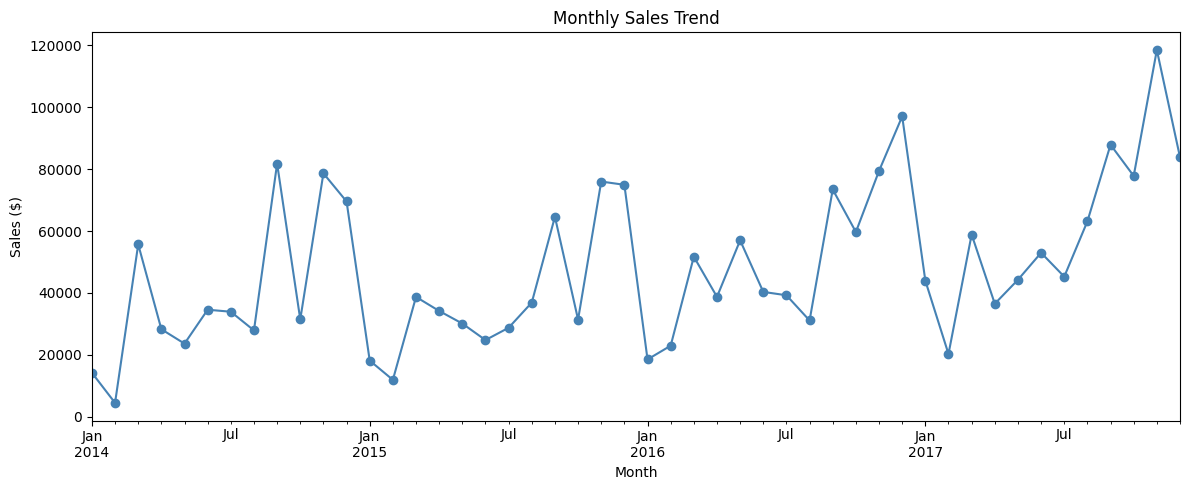

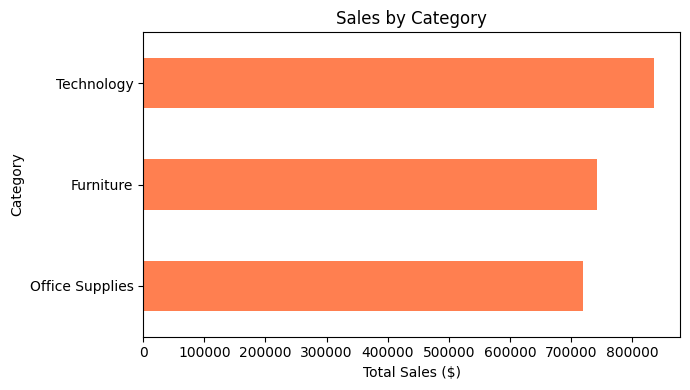

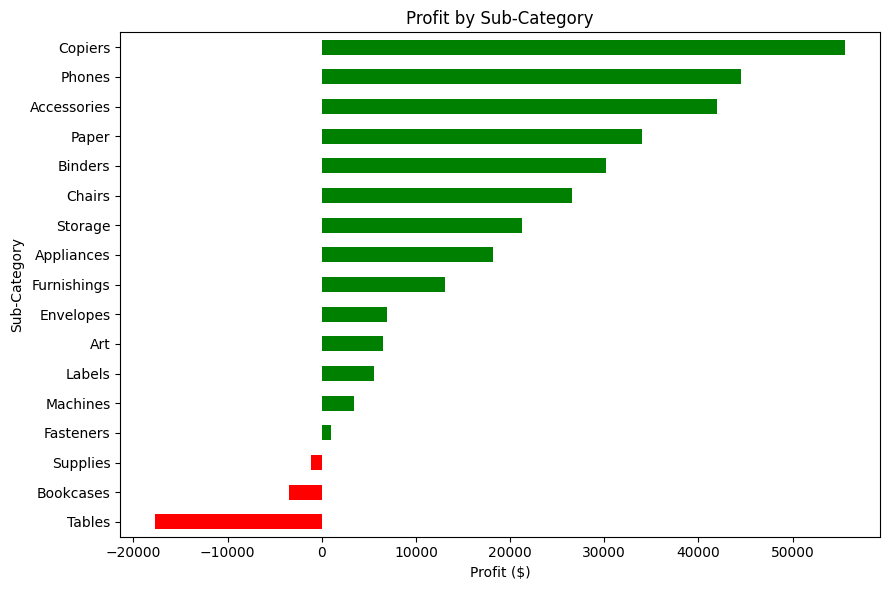

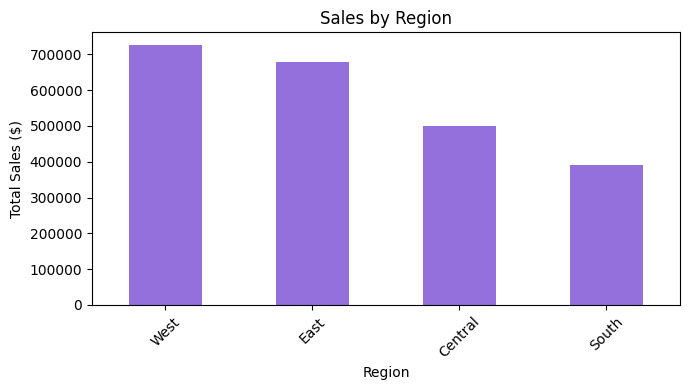

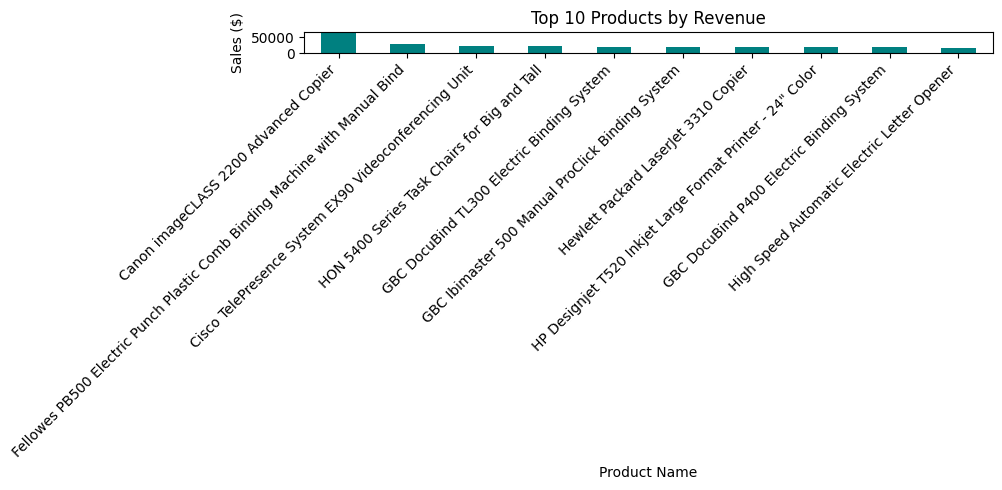

✅ All 5 charts saved!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')

# --- Chart 1: Monthly Sales Trend ---
monthly_sales = df.groupby('Month')['Sales'].sum()
plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('monthly_sales.png')
plt.show()

# --- Chart 2: Sales by Category ---
category_sales = df.groupby('Category')['Sales'].sum().sort_values()
plt.figure(figsize=(7,4))
category_sales.plot(kind='barh', color='coral')
plt.title('Sales by Category')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('category_sales.png')
plt.show()

# --- Chart 3: Profit by Sub-Category ---
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
plt.figure(figsize=(9,6))
colors = ['green' if x > 0 else 'red' for x in sub_profit]
sub_profit.plot(kind='barh', color=colors)
plt.title('Profit by Sub-Category')
plt.xlabel('Profit ($)')
plt.tight_layout()
plt.savefig('subcategory_profit.png')
plt.show()

# --- Chart 4: Sales by Region ---
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(7,4))
region_sales.plot(kind='bar', color='mediumpurple')
plt.title('Sales by Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('region_sales.png')
plt.show()

# --- Chart 5: Top 10 Products ---
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_products.plot(kind='bar', color='teal')
plt.title('Top 10 Products by Revenue')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()

print("✅ All 5 charts saved!")

In [7]:
# Save all insights to a text file
insights = """
BUSINESS SALES PERFORMANCE ANALYSIS
=====================================
Dataset: Superstore Sales | Tool: Python (pandas, matplotlib)

KEY INSIGHTS & RECOMMENDATIONS
--------------------------------
1. OVERALL: Total Sales = $2,297,200 | Profit = $286,397 | Margin = 12.5%
   → Profitability can be improved despite strong revenue.

2. CATEGORY: Technology leads in revenue.
   → Prioritize marketing and stock for Technology category.

3. PROFIT WARNING: Tables & Bookcases have NEGATIVE profit.
   → Reprice or discontinue these sub-categories immediately.

4. REGION: West is strongest. South is weakest.
   → Investigate South region performance and cut losses or boost promotions.

5. TREND: Sales peak in Nov-Dec (Q4 holiday season).
   → Plan inventory and campaigns ahead of Q4 every year.

6. TOP PRODUCTS: Top 10 products drive majority of revenue.
   → Protect these products with consistent stock and promotions.
"""

with open("business_insights.txt", "w") as f:
    f.write(insights)

print("✅ Insights saved to business_insights.txt")

✅ Insights saved to business_insights.txt
